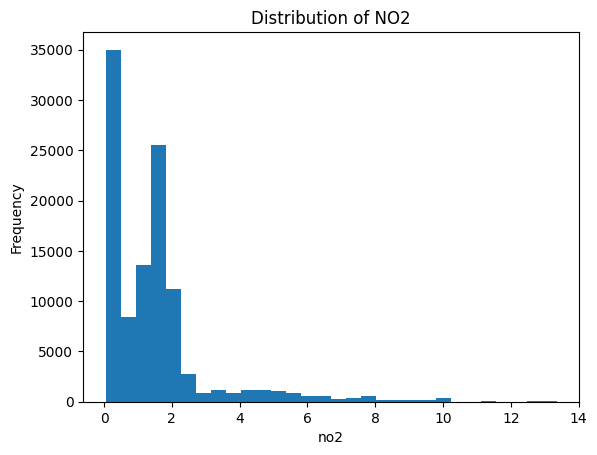

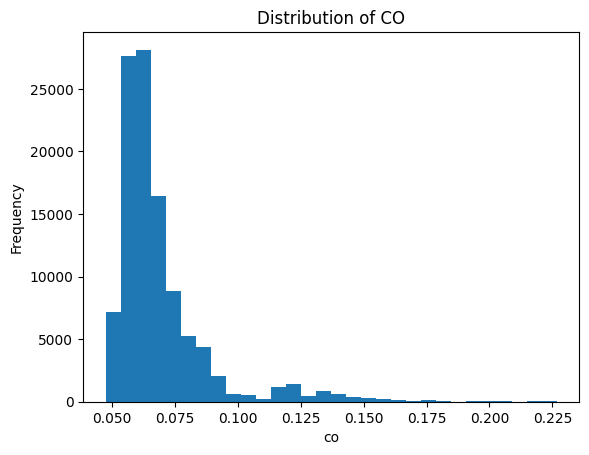

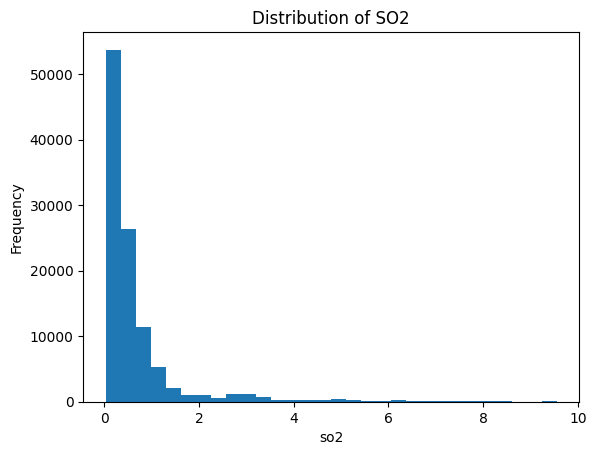

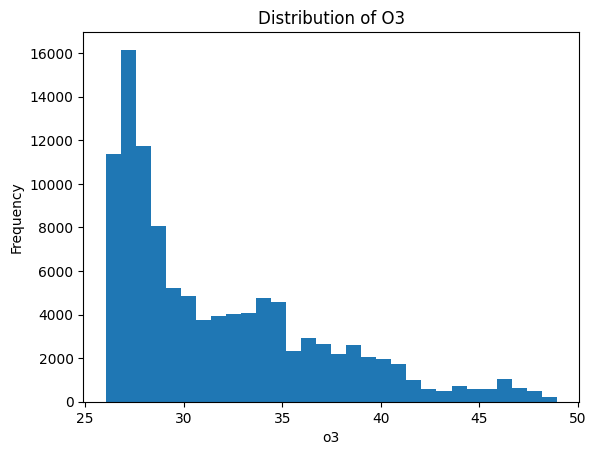

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("phq2_raw.csv")

df.head()

cols = ['no2', 'co', 'so2', 'o3']

for col in cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col.upper()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [4]:
thresholds = {}

for col in cols:
    q33 = df[col].quantile(0.33)
    q66 = df[col].quantile(0.66)
    
    thresholds[col] = (q33, q66)
    
    print(f"{col.upper()}:")
    print(f"  Trace <= {q33:.2f}")
    print(f"  Moderate <= {q66:.2f}")
    print(f"  Heavy > {q66:.2f}\n")

NO2:
  Trace <= 0.50
  Moderate <= 1.64
  Heavy > 1.64

CO:
  Trace <= 0.06
  Moderate <= 0.07
  Heavy > 0.07

SO2:
  Trace <= 0.20
  Moderate <= 0.52
  Heavy > 0.52

O3:
  Trace <= 28.07
  Moderate <= 33.22
  Heavy > 33.22



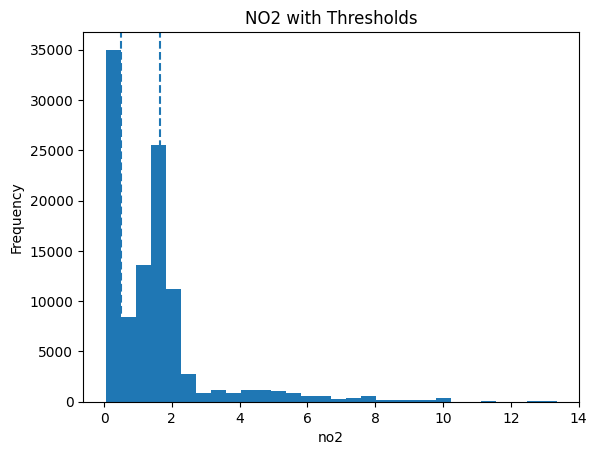

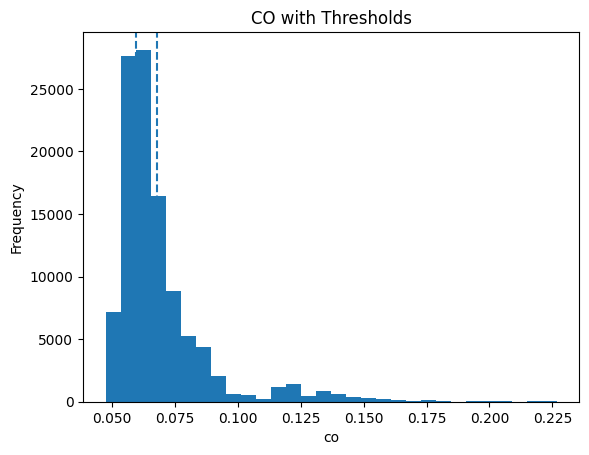

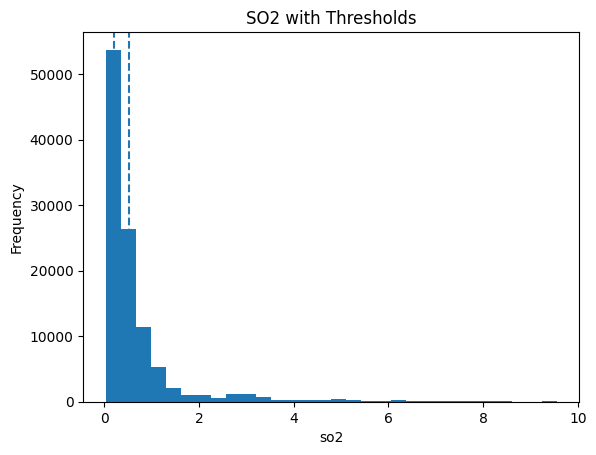

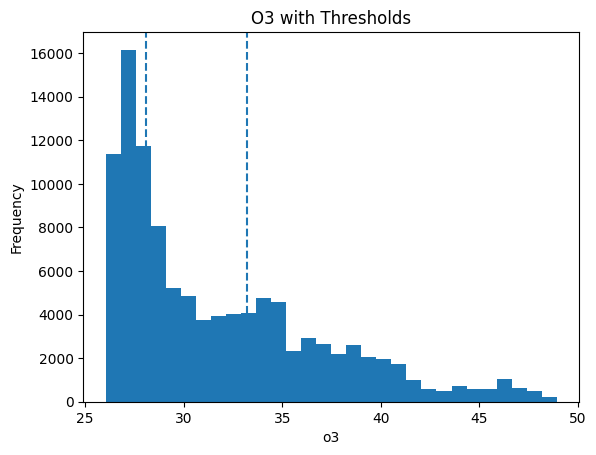

In [5]:
for col in cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    
    q33, q66 = thresholds[col]
    
    plt.axvline(q33, linestyle='--')
    plt.axvline(q66, linestyle='--')
    
    plt.title(f'{col.upper()} with Thresholds')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()